# Forecast of Customer Churn for the Telecommunications Provider “TeleDom”

The telecommunications provider “TeleDom” offers landline telephone and internet access services. The company provides customers with a wide range of additional services — from cloud storage and antivirus protection to streaming TV. However, in recent months, the company has faced an increase in customer churn, leading to a decline in profits and higher costs for acquiring new users.

The goal of the project is to develop a machine learning model that will predict the probability of customer churn. (This will allow the company to identify users likely to churn in advance and offer them personalized promotions, discounts, and promo codes.
In this way, the solution will help reduce churn, increase customer loyalty, and optimize marketing expenses.)

Project Plan:
- Data loading
- Data frame preprocessing
- Data integration
- Exploratory analysis
- Data preparation for modeling
- Training machine learning models
- Selecting the best model
- Overall conclusions and recommendations for the client

*In all files, the “customerID” column contains the customer ID. Contract information is current as of February 1, 2020.*

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.pipeline import Pipeline

from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.impute import SimpleImputer

from phik import phik_matrix
from phik.report import plot_correlation_matrix

## Loading Data

In [4]:
data_contract = pd.read_csv('contract_new.csv',
                                parse_dates=[1,2],
                                dtype={'Total_Charges':float, 'MounthliCharges':float})
data_personal = pd.read_csv('personal_new.csv')
data_internet = pd.read_csv('internet_new.csv')
data_phone = pd.read_csv('phone_new.csv')

C:\Users\Player\AppData\Local\Temp\ipykernel_34448\3272186278.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_contract = pd.read_csv('contract_new.csv',


The data consists of several files obtained from various sources:
- contract_new.csv — contract information;
- personal_new.csv — customer personal information;
- internet_new.csv — information about internet services;
- phone_new.csv — information about telephone services.

## Data Preprocessing

### Preprocessing data_contract

In [8]:
data_contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 440.3+ KB


There are no missing values in the table. The data types are incorrectly assigned: EndDate, TotalCharges

In [10]:
data_contract

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,2035.2
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7430.4
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,325.6
7041,8361-LTMKD,2019-07-01,No,Month-to-month,Yes,Mailed check,74.40,520.8


There are customers who have not terminated their contracts, so their EndDate is “No.” For further analysis, let's create a target attribute called ContractEnded using EndDate, and change the EndDate type to datetime64.


In [12]:
data_contract['ContractEnded'] = data_contract['EndDate'].apply(lambda x: 1 if x != "No" else 0)

In [13]:
data_contract['EndDate'] = data_contract['EndDate'].replace('No', pd.NaT)
data_contract['EndDate'] = pd.to_datetime(data_contract['EndDate'])

Let's also change the data type of TotalCharges.

In [15]:
data_contract['TotalCharges'] = pd.to_numeric(data_contract['TotalCharges'], errors='coerce')

In [16]:
data_contract[data_contract['TotalCharges'].isna()]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ContractEnded
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,NaN,0
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,NaN,0
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,NaN,0
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,NaN,0
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,NaN,0
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,NaN,0
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,NaN,0


The new line items in TotalCharges are only available as of February 1, 2020.

In [18]:
data_contract[data_contract['BeginDate'] == '2020-02-01']

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ContractEnded
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,NaN,0
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,NaN,0
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,NaN,0
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,NaN,0
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,NaN,0
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,NaN,0
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,NaN,0


In [19]:
data_contract['BeginDate'].max()

Timestamp('2020-02-01 00:00:00')

In [20]:
data_contract['TotalCharges'] = data_contract['TotalCharges'].fillna(data_contract['MonthlyCharges'])

- Missing values in the TotalCharges column are observed only for customers who signed a contract on 2020-02-01, that is, on the last day of the observation period.
- For these customers, cumulative charges have not yet been calculated, so we populate the TotalCharges values with their monthly charges (MonthlyCharges).

Duplicate Check

In [23]:
data_contract.duplicated(subset=['customerID']).sum()

0

There are no obvious duplicates.

In [25]:
data_contract['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [26]:
data_contract['Type'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

There are no implicit duplicates.

### Preprocessing of `data_personal`

In [29]:
data_personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


The data types are assigned correctly; there are no missing values.

In [31]:
data_personal

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes
7039,2234-XADUH,Female,0,Yes,Yes
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No


Duplicate Check

In [33]:
data_personal.duplicated(subset=['customerID']).sum()

0

In [34]:
data_personal['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [35]:
data_personal['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [36]:
data_personal['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

There are no explicit or implicit duplicates

### Preprocessing  internet_new

In [39]:
data_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


There are no gaps; the data types are assigned correctly.

In [41]:
data_internet

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...
5512,6840-RESVB,DSL,Yes,No,Yes,Yes,Yes,Yes
5513,2234-XADUH,Fiber optic,No,Yes,Yes,No,Yes,Yes
5514,4801-JZAZL,DSL,Yes,No,No,No,No,No
5515,8361-LTMKD,Fiber optic,No,No,No,No,No,No


In [42]:
data_internet.duplicated(subset=['customerID']).sum()

0

In [43]:
for name in data_internet.columns[1:]:
    print(data_internet[name].unique())

['DSL' 'Fiber optic']
['No' 'Yes']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']


There are no explicit or implicit duplicates.

### Preprocessing  data_phone

In [46]:
data_phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


There are no missing values, and the data types are correct.

In [48]:
data_phone

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
...,...,...
6356,2569-WGERO,No
6357,6840-RESVB,Yes
6358,2234-XADUH,Yes
6359,8361-LTMKD,Yes


In [49]:
data_phone.duplicated(subset=['customerID']).sum()

0

In [50]:
data_phone['MultipleLines'].unique()

array(['No', 'Yes'], dtype=object)

No duplicates.

### Conclusion
Initially, four datasets were obtained:
 - data_contract (7043x7)
  - In the TotalCharges column, missing values were replaced with monthly charges
  - A new attribute, ContractEnded, was added, where 1 indicates the contract was terminated and 0 indicates it was renewed.
 - data_personal (7043x5)
 - data_internet (5517x7)
 - data_phone (6361x2)

## Data Integration

We join the data using the `how=‘left’` parameter to retain all rows from the `data_contract` table. We leave the empty values in the `internet` and `phone` columns as they are, since some customers did not use these services but still signed a contract.

In [55]:
df = data_contract.merge(data_personal, on='customerID', how='left')
df = df.merge(data_internet, on='customerID', how='left')
df = df.merge(data_phone, on='customerID', how='left')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           1101 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   ContractEnded     7043 non-null   int64         
 9   gender            7043 non-null   object        
 10  SeniorCitizen     7043 non-null   int64         
 11  Partner           7043 non-null   object        
 12  Dependents        7043 non-null   object        
 13  InternetService   5517 non-null   object        
 14  OnlineSecurity    5517 n

We fill in the gaps created by the merge and insert placeholders

In [58]:
for col in data_internet.columns[1:]:
    df[col] = df[col].fillna('No internet service')

In [59]:
df['MultipleLines'] = df['MultipleLines'].fillna('No phone service')

Let's create a new attribute called “contract duration” to resolve the issue of missing values in EndDate

We save the date of the analysis to calculate the contract duration

In [62]:
last_date = pd.Timestamp('2020-02-01')

In [63]:
df['ContractDuration'] = (df['EndDate'].fillna(last_date) - df['BeginDate']).dt.days

### Conclusion
Four data frames were merged:
- A new attribute, ContractDuration, was added to indicate the contract duration.
- The gaps in the InternetService and MultipleLines fields that appeared during the merge were filled with the placeholders “No internet service” and “No phone service,” respectively. 

## Research Analysis 

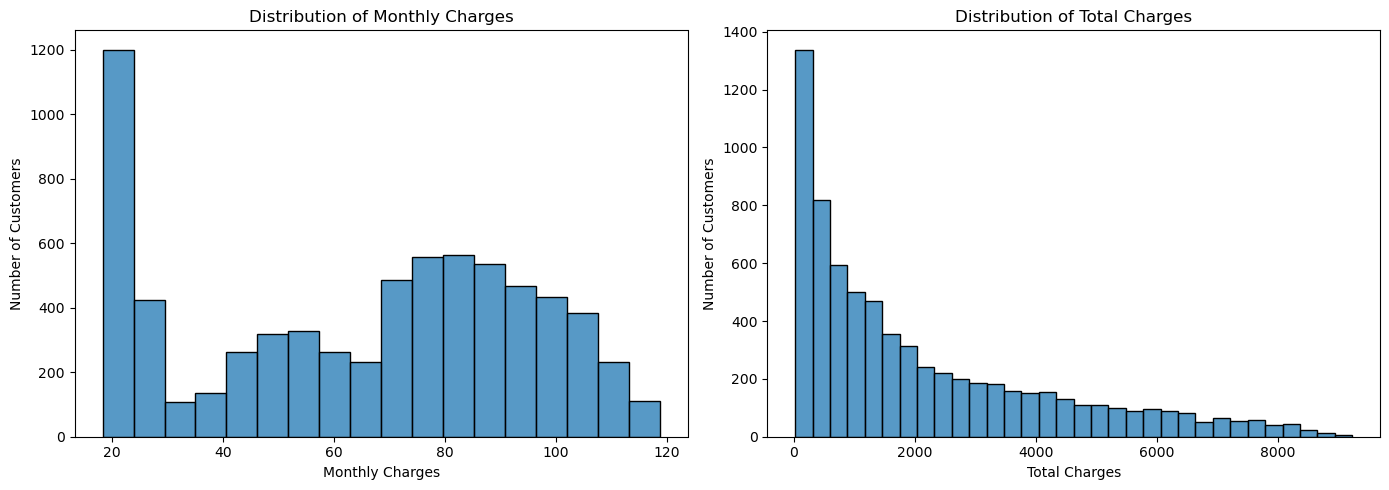

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly charges distribution
sns.histplot(data=df, x='MonthlyCharges', ax=axes[0])
axes[0].set_title('Distribution of Monthly Charges')
axes[0].set_xlabel('Monthly Charges')
axes[0].set_ylabel('Number of Customers')

# Total charges distribution
sns.histplot(data=df, x='TotalCharges', ax=axes[1])
axes[1].set_title('Distribution of Total Charges')
axes[1].set_xlabel('Total Charges')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

Most customers have very few expenses (close to 0)

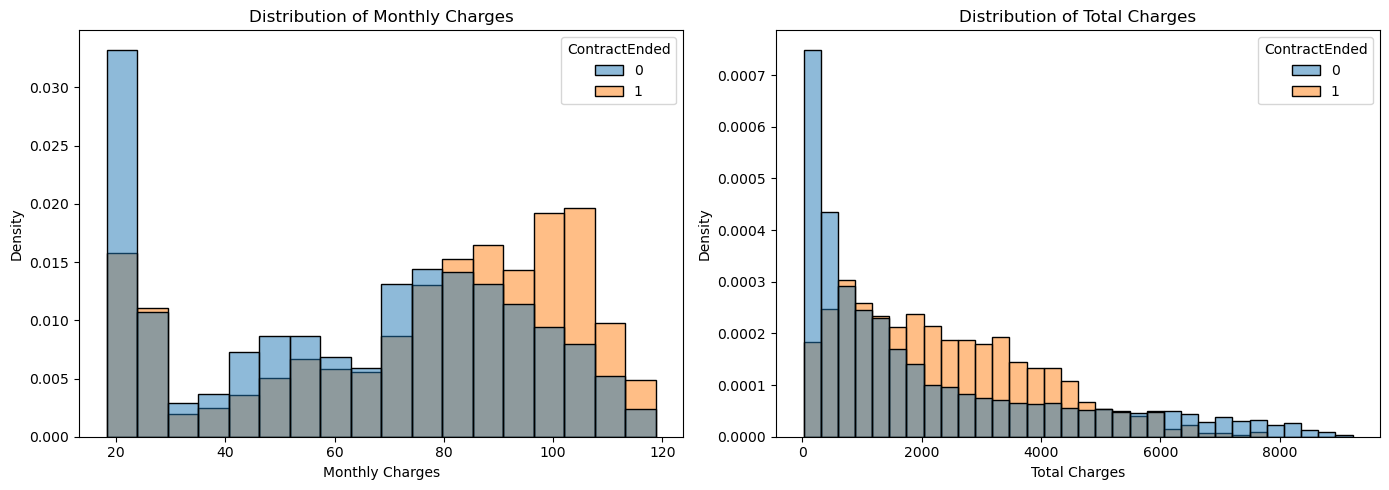

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly charges distribution
sns.histplot(data=df, x='MonthlyCharges', ax=axes[0], hue='ContractEnded', stat='density', common_norm=False)
axes[0].set_title('Distribution of Monthly Charges')
axes[0].set_xlabel('Monthly Charges')
axes[0].set_ylabel('Density')

# Total charges distribution
sns.histplot(data=df, x='TotalCharges', ax=axes[1], hue='ContractEnded', stat='density', common_norm=False)
axes[1].set_title('Distribution of Total Charges')
axes[1].set_xlabel('Total Charges')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

- The higher the monthly fee, the greater the likelihood of contract termination
- The higher the customer's total spending, the lower the likelihood of contract termination

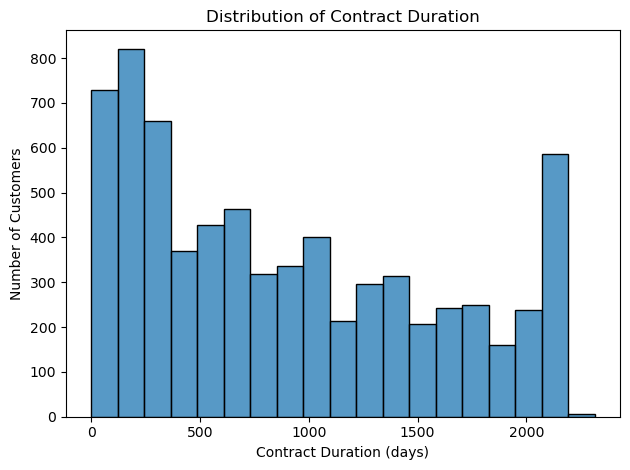

In [70]:
sns.histplot(data=df, x='ContractDuration')
plt.title('Distribution of Contract Duration')
plt.xlabel('Contract Duration (days)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

- Most customers have a short service period—less than 500 days, or about a year and a half.

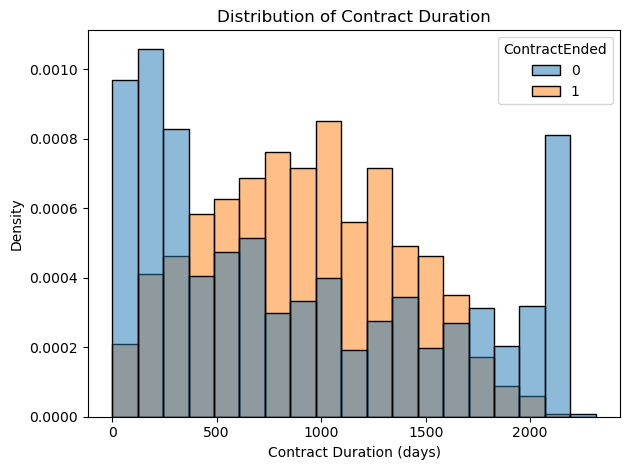

In [72]:
sns.histplot(data=df, x='ContractDuration', hue='ContractEnded', stat='density', common_norm=False)
plt.title('Distribution of Contract Duration')
plt.xlabel('Contract Duration (days)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

- Among customers with long-term contracts (1,500–2,000 days) and those with contracts that have just been signed (<400 days), there is a noticeably lower customer churn rate.

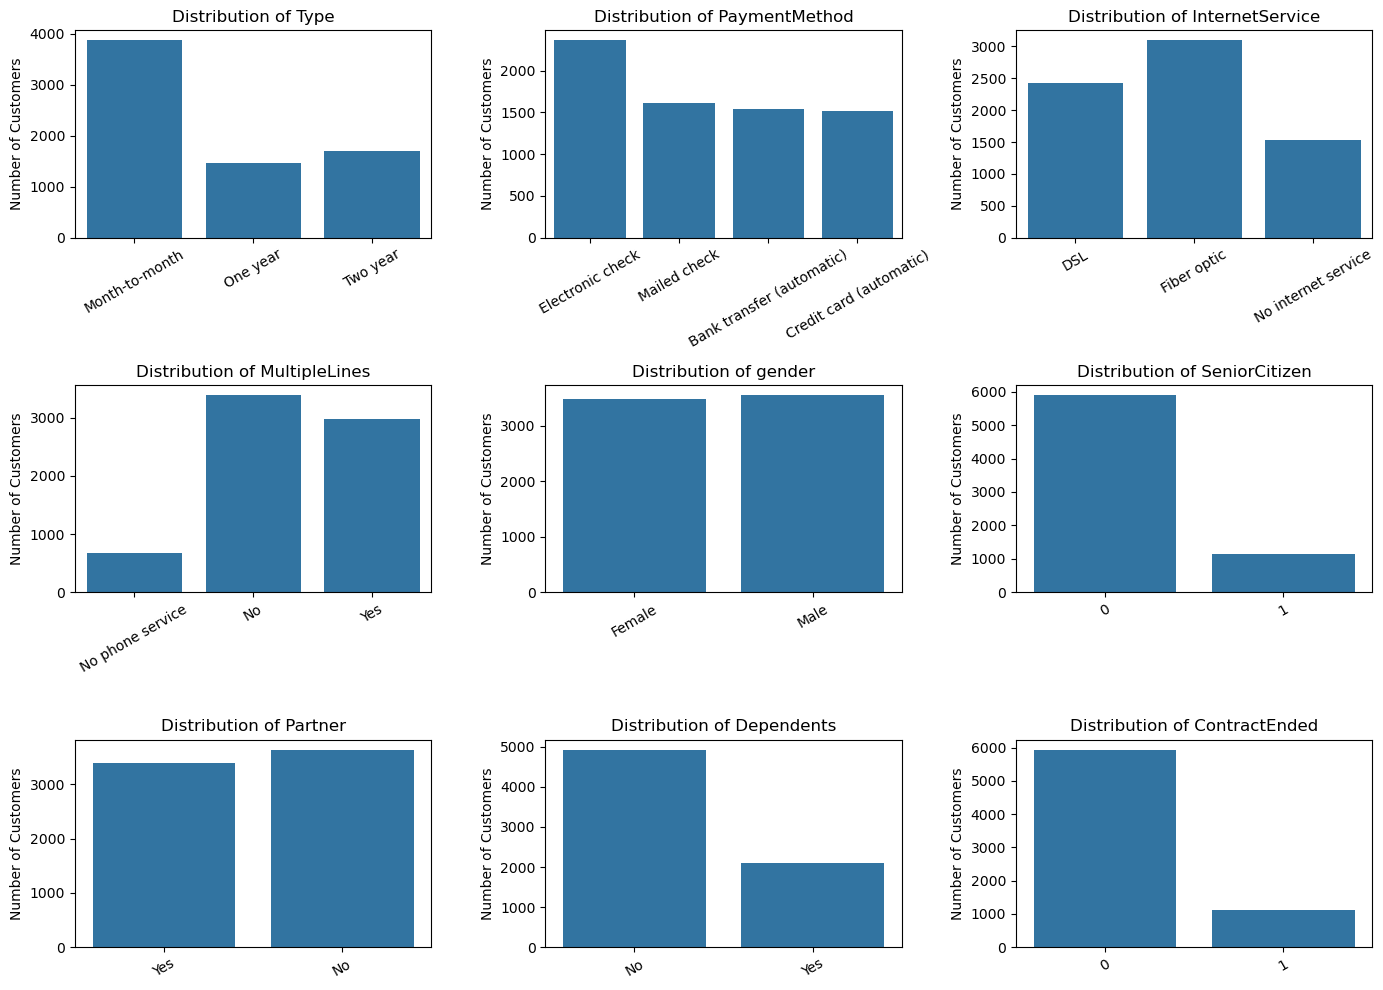

In [74]:
cols = [
    'Type', 'PaymentMethod', 'InternetService', 'MultipleLines',
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'ContractEnded'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))  # 3x3 grid
axes = axes.flatten()  # convert the axes matrix into a list

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Number of Customers')
    axes[i].tick_params(axis='x', rotation=30)

# remove unused axes if there are fewer plots than cells
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

An analysis of categorical variables revealed the following:

- Most customers have a monthly contract.

- Electronic payment is the most popular payment method.

- “Fiber optic” has the largest number of customers.

- Most customers do not have multiple lines or do not have telephone service.

- The number of female and male customers is roughly equal.

- Most customers are not senior citizens (marked as 0).

- The number of customers with and without a partner is roughly the same.

- Most customers do not have children.

- Most customers have not terminated their contract (about 6,000); 1,000 have terminated theirs.


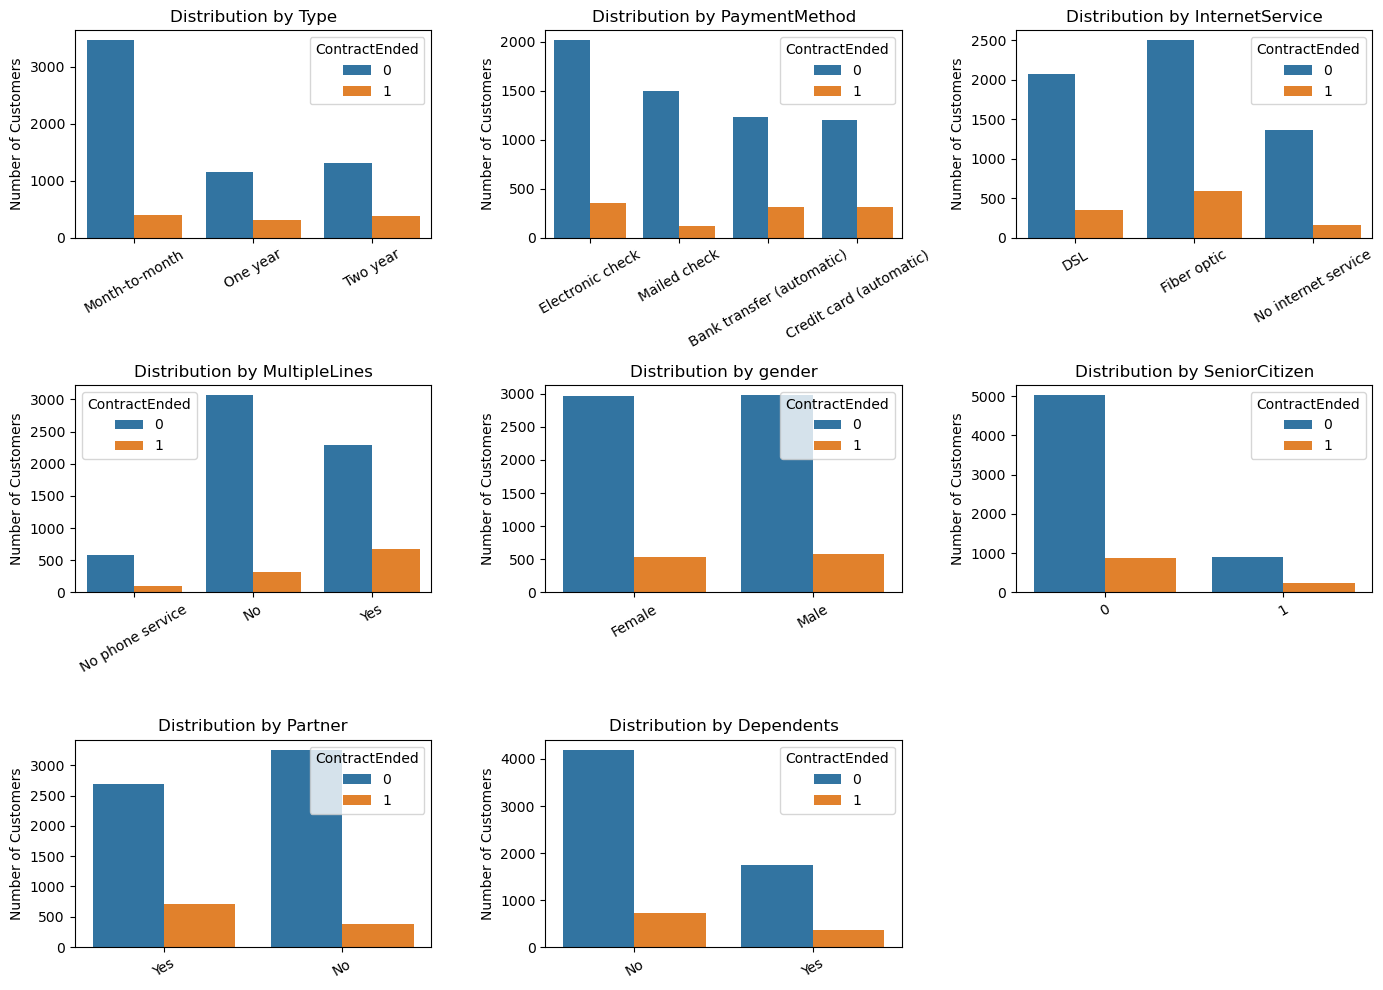

In [76]:
cols = [
    'Type', 'PaymentMethod', 'InternetService', 'MultipleLines',
    'gender', 'SeniorCitizen', 'Partner', 'Dependents'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))  # 3x3 grid
axes = axes.flatten()  # convert axes matrix to list

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue='ContractEnded')
    axes[i].set_title(f'Distribution by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Number of Customers')
    axes[i].tick_params(axis='x', rotation=30)

# remove extra empty subplots
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Patterns observed in the following indicators:
- Customers who pay by “mailed check” are the least likely to renew their contracts
- Fiber optic customers are less loyal
- Customers with multiple lines are more likely not to renew their contracts



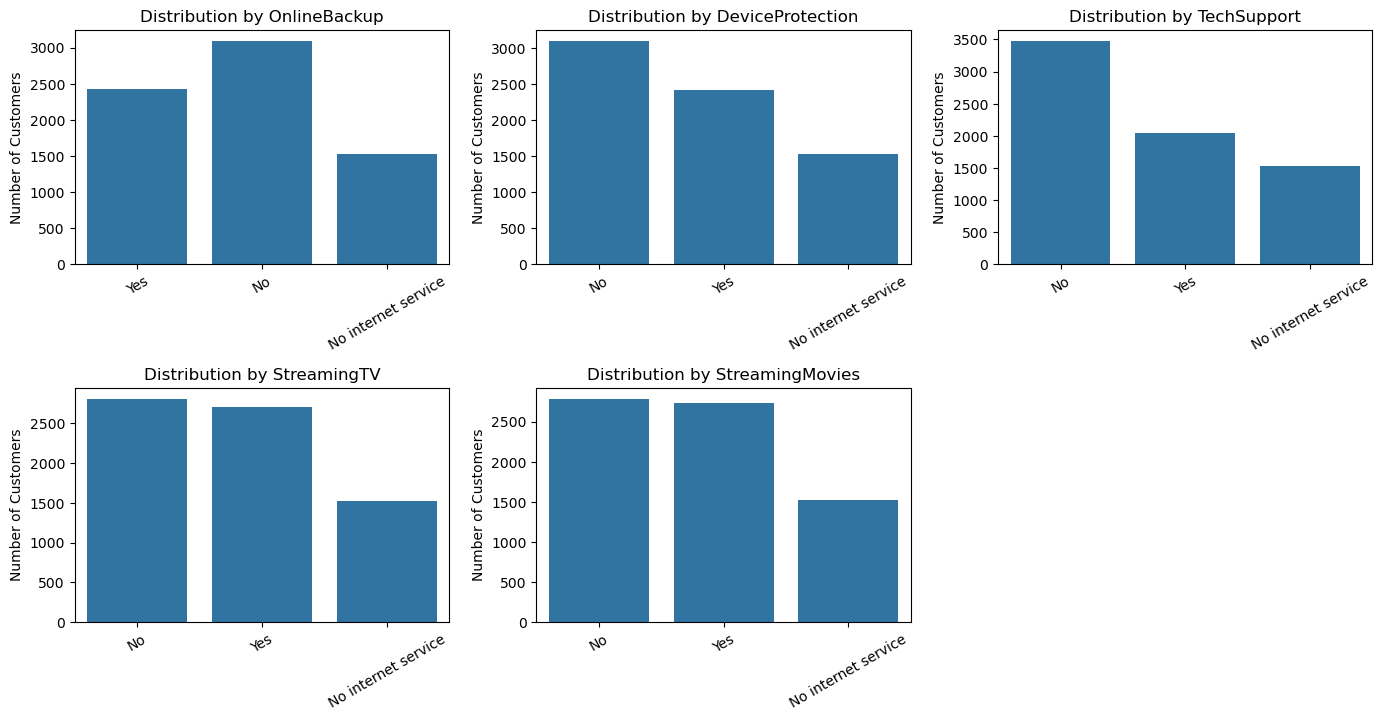

In [78]:
cols = [
   'OnlineBackup', 'DeviceProtection',
   'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))  # 3x3 grid
axes = axes.flatten()  # convert axes matrix to list

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Number of Customers')
    axes[i].tick_params(axis='x', rotation=30)

# remove extra empty subplots
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Most people do not use the Internet services provided by the telecom company.


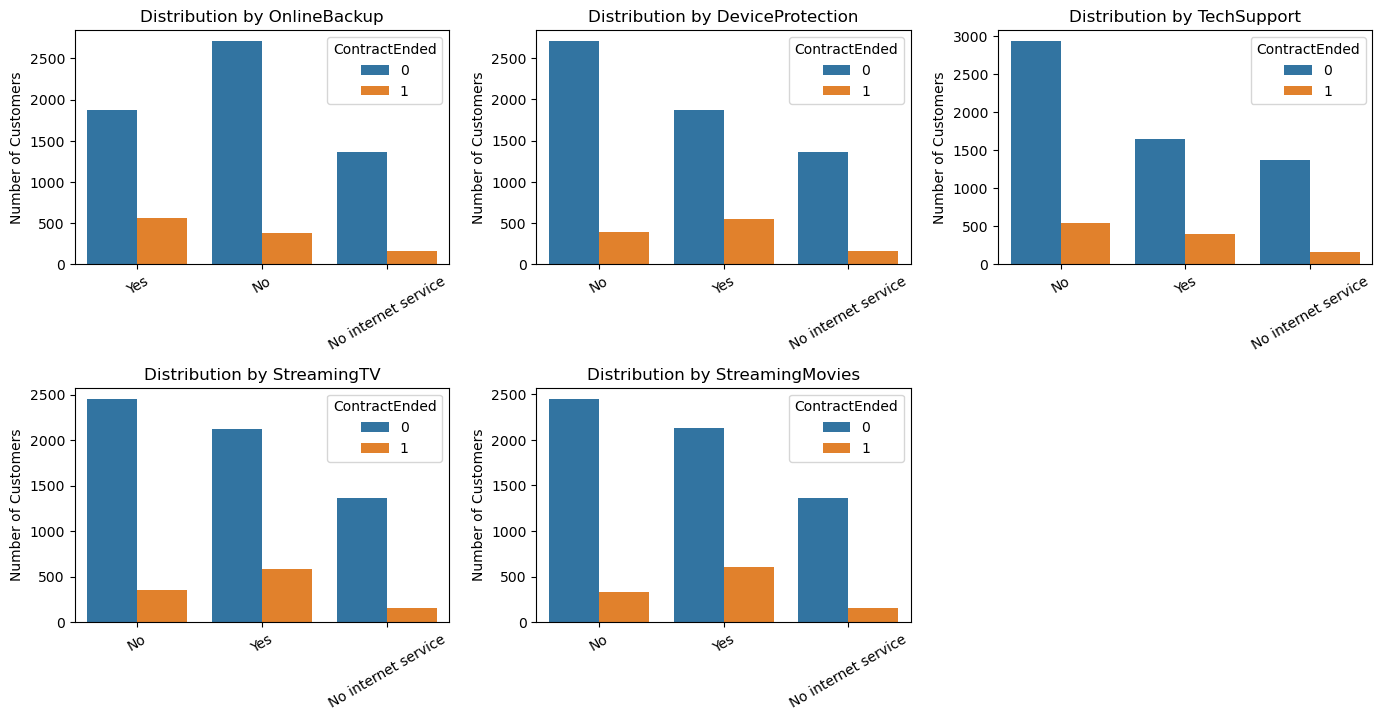

In [80]:
cols = [
   'OnlineBackup', 'DeviceProtection',
   'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))  # 3x3 grid
axes = axes.flatten()  # convert axes matrix to list

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue='ContractEnded')
    axes[i].set_title(f'Distribution by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Number of Customers')
    axes[i].tick_params(axis='x', rotation=30)

# remove extra empty subplots
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

No particular patterns were identified.


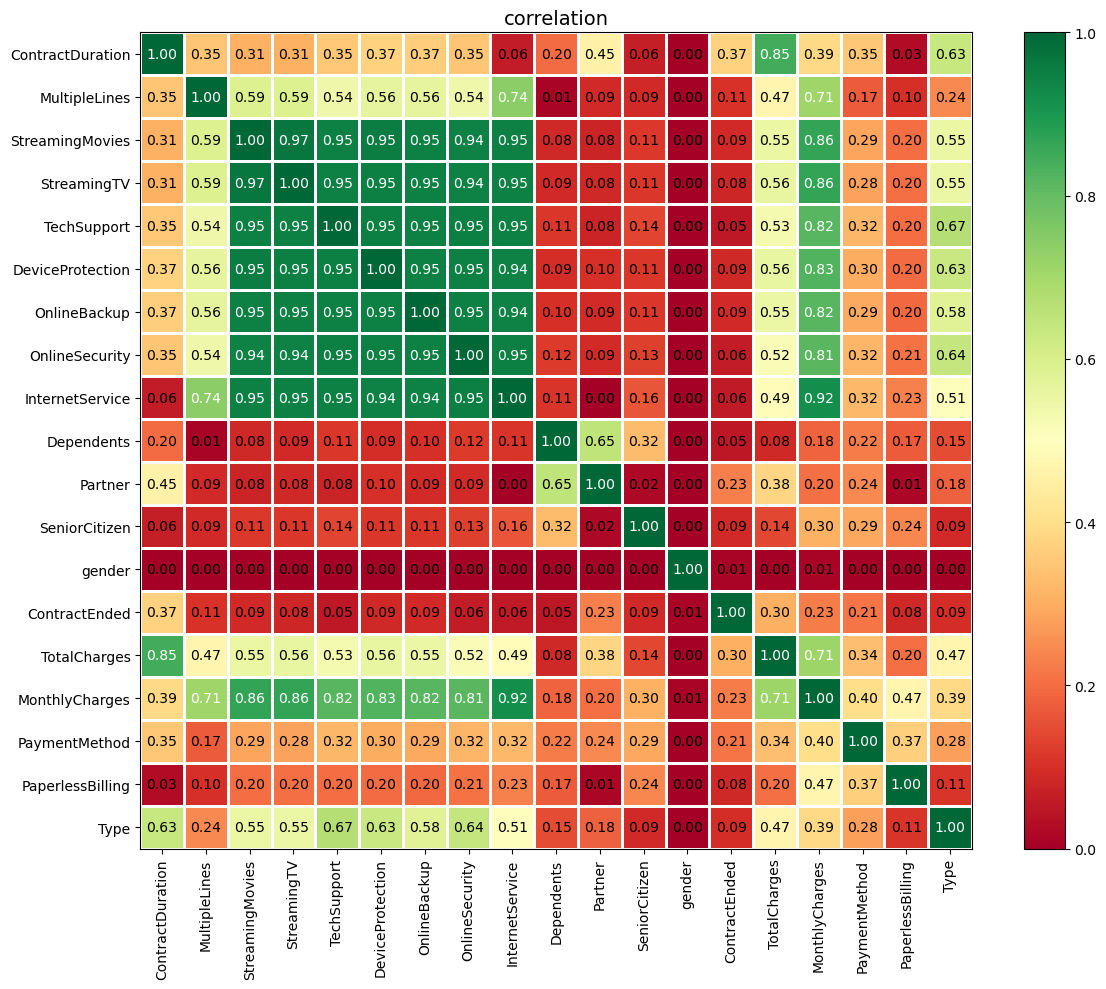

In [82]:
interval_cols = ['MonthlyCharges', 'TotalCharges', 'ContractDuration']

phik_corr = df.drop(['customerID','BeginDate','EndDate'],axis=1).phik_matrix(interval_cols=interval_cols);

# Visualisation
plot_correlation_matrix(phik_corr.values,
                        x_labels=phik_corr.columns,
                        y_labels=phik_corr.index,
                        vmin=0, vmax=1,
                        figsize=(12, 10));

- There is a very weak correlation between the target variable and the input features; the correlations with the ContractDuration and TotalCharges features are weak (0.37 and 0.3, respectively).
- Multicorrelation is observed among the input features (for example, between TotalCharges and ContractDuration (0.85), MonthlyCharges and InternetServices (0.92), and among all features in the “internet” dataset). However, despite this, the features do not logically duplicate one another and may be important for model building; therefore, it was decided to retain them.


### Conclusion 
During the analysis:
- The data is characterized by a significant class imbalance with respect to the target variable, a weak correlation between features and churn, and the presence of multicollinearity.
- Key features that may influence the model:

 - MonthlyCharges - monthly charges.
 
 - TotalCharges — total expenses.

 - ContractDuration — contract duration.

 - TotalCharges — the customer’s total expenses.

 - PaymentMethod — payment method (e.g., “Mailed check”).

  - MultipleLines — presence of multiple lines.

  - InternetService — type of internet connection (e.g., “Fiber optic”).

## Training and Analysis of a Machine Learning Model

### Data Preparation

In [87]:
X = df.drop(['customerID','BeginDate','EndDate','ContractEnded'],axis=1)

In [88]:
y = df['ContractEnded']

In [89]:
num_columns = ['MonthlyCharges', 'TotalCharges', 'ContractDuration']

In [90]:
ohe_columns = ['Type','PaymentMethod','InternetService','MultipleLines']

In [91]:
ord_columns = ['PaperlessBilling','gender','Partner','Dependents','OnlineSecurity','OnlineBackup','DeviceProtection',
                 'TechSupport','StreamingTV','StreamingMovies']

Pipeline for OneHotEncoder

In [93]:
ohe_pipe = Pipeline(
    [
            ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
            ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]
) 

Pipeline for OrdinalEncoder

In [95]:
ord_pipe = Pipeline(
    [
            ('simpleImputer_le', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
            ('le', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]
) 

Numerical data pipeline.

In [97]:
num_pipe = Pipeline([
    ('scaler', StandardScaler())
])

In [98]:
data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_columns),
    ('ord', ord_pipe, ord_columns),
    ('num', num_pipe, num_columns),
    ('pass_senior', 'passthrough', ['SeniorCitizen'])  # Leave it as is
])

In [99]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LogisticRegression(solver='liblinear', random_state=61125))
    ]
)


In [100]:
param_grid = [
    {
        'models': [LogisticRegression(solver='liblinear', random_state=61125)],
        'models__C': [0.01, 0.1, 1, 10],
        'models__penalty': ['l1', 'l2'],
        'models__class_weight': [None, 'balanced']
    },

    {
        'models': [DecisionTreeClassifier(random_state=61125)],
        'models__max_depth': [3, 5],
        'models__min_samples_split': [2, 5],
        'models__min_samples_leaf': [2, 4]
    },

    {
        'models': [LGBMClassifier(random_state=61125, colsample_bytree=1)],
        'models__n_estimators': [200, 300, 500],      # slightly lower to reduce overfitting
        'models__learning_rate': [0.01, 0.05, 0.1],   # slower learning
        'models__max_depth': [2, 4],                  # limit tree depth
        'models__reg_lambda': [3],                   # stronger regularization
        'models__reg_alpha': [0.1],                  # L1 regularization
        'models__subsample': [0.7],                  # row sampling to reduce overfitting
    }  
]

We use StratifiedKFold so that each fold has roughly the same class ratio as in the original dataset.

In [102]:
cv = StratifiedKFold(n_splits=4)

In [103]:
grid_search = GridSearchCV(
    estimator=pipe_final,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=61125, stratify = y)

### Model Training and Training Results

In [106]:
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 42 candidates, totalling 168 fits
[LightGBM] [Info] Number of positive: 826, number of negative: 4456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000242 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 740
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.156380 -> initscore=-1.685412
[LightGBM] [Info] Start training from score -1.685412
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

GridSearchCV(cv=StratifiedKFold(n_splits=4, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['Type',
                                                                          'PaymentMethod',
                                                                          'InternetService',
                                                                          'MultipleLi...
                          'models__max_depth': [3, 5],
                          'models__min_samples_leaf': [2, 4],
                          'models__min_samples_split': [2, 5]},
                         {'models': [LGBMClassifier(colsample_bytree=1,
                                                    random_state=61125)],
                          'models__learning_rate': [0.01, 0.05, 0.1],
                          'models__max_depth': [2, 4],
                          'models__n_estimators': [200, 300, 500],
                          'models__reg_alpha': [0.1], 'models__reg_lambda': [3],
                          'models__subsample': [0.7]}],
             scoring='roc_auc', verbose=2)

In [107]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Type', 'PaymentMethod',
                                                   'InternetService',
                                                   'MultipleLines']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_le',
                                                                   SimpleImputer(strategy='most_frequen...
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges',
                                                   'ContractDuration']),
                                                 ('pass_senior', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('models',
                 LGBMClassifier(colsample_bytree=1, max_depth=4,
                                n_estimators=500, random_state=61125,
                                reg_alpha=0.1, reg_lambda=3, subsample=0.7))])

In [108]:
grid_search.best_params_

{'models': LGBMClassifier(colsample_bytree=1, random_state=61125),
 'models__learning_rate': 0.1,
 'models__max_depth': 4,
 'models__n_estimators': 500,
 'models__reg_alpha': 0.1,
 'models__reg_lambda': 3,
 'models__subsample': 0.7}

In [109]:
grid_search.best_score_

0.8797807265061872

Based on the results of GridSearchCV, LGBM emerged as the best model, with a ROC AUC of 0.9 on the validation data.

In [111]:
model = grid_search.best_estimator_

In [112]:
predictions = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]

In [113]:
roc_auc_score(y_test, pred_proba)

0.8900575064235899

In [114]:
accuracy_score(y_test,predictions)

0.9063032367972743

On the test data, the model achieves a roc_auc_score of 0.89 and an accuracy_score of 0.91—out of 100 customers, the model correctly identifies the status of 91 customers.

### Analysis of the resulting model


In [117]:
# Calculate feature importance
importances = model.named_steps['models'].feature_importances_

Creating a chart showing the importance of characteristics

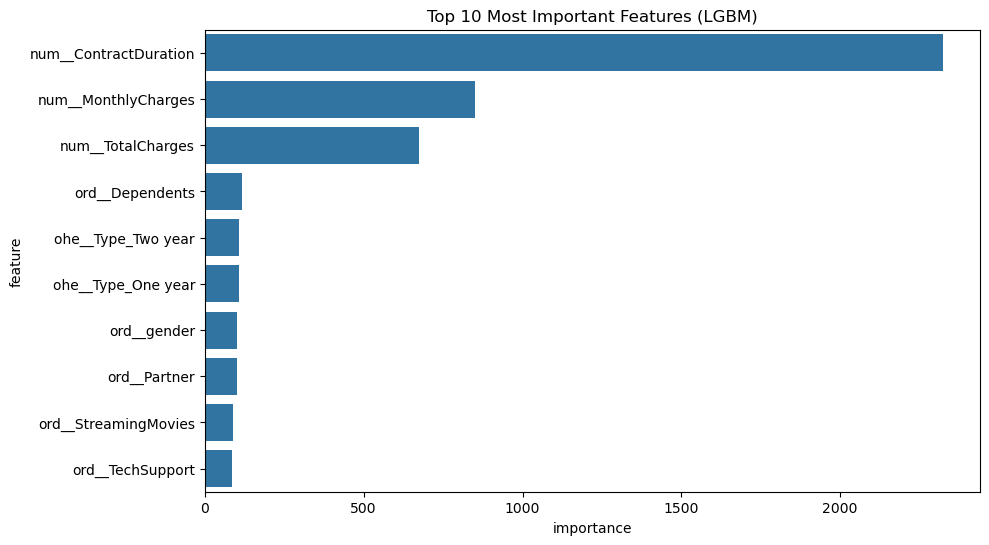

In [119]:
# Get feature names after transformation
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))  # top 10
plt.title('Top 10 Most Important Features (LGBM)')
plt.show()

The most important factors turned out to be numerical factors, contract duration, monthly expenses, and total expenses.

Building an error matrix 

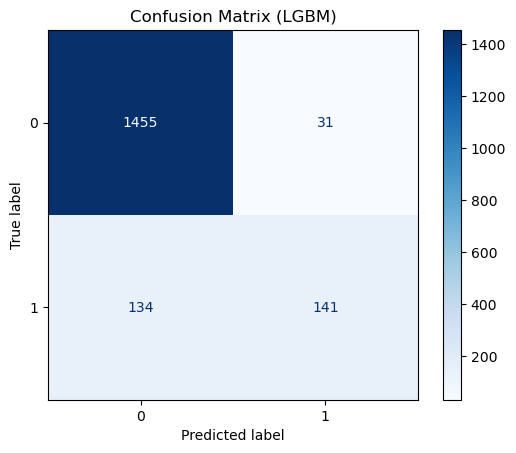

In [122]:
# Creation of confusion matrix
cm = confusion_matrix(y_test, predictions)

# Visualisation
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (LGBM)')
plt.show()

The confusion matrix shows that the model more often incorrectly predicts that a customer will stay (FN = 134) than that they will churn (FP = 31). At the same time, the number of correctly predicted customers is approximately 1,500. From a business perspective, this is an acceptable balance between identifying churning customers and saving on retention campaigns.

## Conclusion

In this project, a machine learning model was developed to predict customer churn for the telecom operator “TeleDom”. After merging and preprocessing data from multiple sources, as well as performing feature analysis, the model was trained while taking into account a strong class imbalance and the presence of multicollinearity.

The best-performing model according to GridSearchCV results was LGBM, which demonstrated high predictive performance: ROC AUC = 0.89, accuracy = 0.91 on the test data — meaning that out of 100 customers, the model correctly identifies the status of 91 customers. Feature importance analysis revealed that the most influential factors in predicting churn are ContractDuration, TotalCharges, PaymentMethod, as well as the presence of multiple phone lines (MultipleLines) and the type of internet connection (InternetService).

The confusion matrix shows that the model more often incorrectly predicts that a customer will stay (FN = 134) than that a customer will leave (FP = 31). At the same time, the number of correctly predicted customers is around 1500. From a business perspective, this is an acceptable balance between identifying customers likely to churn and reducing spending on retention campaigns.

Thus, the developed model allows the company to identify in advance customers with a high risk of churn, which creates opportunities for personalized marketing actions and retention strategies, minimizing financial losses and increasing user loyalty.

Business recommenda-ions:

* Focus on additional services: shift attention away from internet services that a significant portion of customers do not use, toward other dir-ctions.

* Personalized offers: provide customers with a high predicted churn risk with special promotions, discounts, or bonuses encouraging contrac- renewal.

* Monitoring key factors: regularly track features influencing churn — such as contract duration and expenses — to timely adjust marketing strategies.
